In [8]:
# ─────────────────────────────────────────────
# CELL 0 — Reload df from Phase 3 (if starting fresh)
# ─────────────────────────────────────────────
import pandas as pd

# Re-run Phase 3's Cell 1 logic to rebuild df
df_users   = pd.read_csv('../data/users.csv')
df_txns    = pd.read_csv('../data/transactions.csv')
df_events  = pd.read_csv('../data/app_events.csv')
df_tickets = pd.read_csv('../data/support_tickets.csv')

success_txns = df_txns[df_txns['status'] == 'success'].copy()
success_txns['txn_date'] = pd.to_datetime(success_txns['txn_date'])

txn_agg = success_txns.groupby('user_id').agg(
    txn_count=('txn_id', 'count'),
    total_spent=('amount', 'sum'),
    avg_txn_amount=('amount', 'mean'),
    last_txn_date=('txn_date', 'max')
).reset_index()

now = pd.Timestamp.now()
txn_agg['days_since_last_txn'] = (now - txn_agg['last_txn_date']).dt.days
txn_agg = txn_agg.drop(columns='last_txn_date')

app_opens = df_events[df_events['event_type'] == 'app_open'].copy()
app_opens['event_date'] = pd.to_datetime(app_opens['event_timestamp']).dt.date

events_agg = app_opens.groupby('user_id').agg(
    app_open_count=('event_id', 'count'),
    active_days=('event_date', 'nunique')
).reset_index()

tickets_agg = df_tickets.groupby('user_id').agg(
    ticket_count=('ticket_id', 'count'),
    avg_satisfaction=('satisfaction_score', 'mean')
).reset_index()

df = df_users[['user_id', 'age', 'city', 'account_type',
                'account_balance', 'kyc_complete', 'churn']].copy()

df = df.merge(txn_agg, on='user_id', how='left')
df = df.merge(events_agg, on='user_id', how='left')
df = df.merge(tickets_agg, on='user_id', how='left')

df['txn_count']           = df['txn_count'].fillna(0)
df['total_spent']         = df['total_spent'].fillna(0)
df['avg_txn_amount']      = df['avg_txn_amount'].fillna(0)
df['days_since_last_txn'] = df['days_since_last_txn'].fillna(999)
df['app_open_count']      = df['app_open_count'].fillna(0)
df['active_days']         = df['active_days'].fillna(0)
df['ticket_count']        = df['ticket_count'].fillna(0)
df['avg_satisfaction']    = df['avg_satisfaction'].fillna(0)

print(f"✅ df rebuilt: {df.shape[0]:,} rows × {df.shape[1]} columns")


df.to_csv('../data/master_features.csv', index=False)
print("✅ Saved: data/master_features.csv")

✅ df rebuilt: 10,000 rows × 15 columns
✅ Saved: data/master_features.csv


In [9]:
# ─────────────────────────────────────────────
#  — Feature Engineering
# Prepare X (features) and y (target) for the model
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np

# df should already exist from Phase 3 — if not, re-run Phase 3 Cell 1 first
print(f"Starting with: {df.shape[0]:,} rows × {df.shape[1]} columns")

df_model = df.copy()

# ── 1. Encode binary/boolean columns ──
# kyc_complete: True/False -> 1/0
df_model['kyc_complete'] = df_model['kyc_complete'].astype(int)

# ── 2. One-Hot Encode categorical columns (city, account_type) ──
# Why one-hot? 'city' has no natural order (Mumbai isn't "more" than Delhi).
# One-hot creates a separate 0/1 column per category — model treats each independently.
df_model = pd.get_dummies(df_model, columns=['city', 'account_type'], drop_first=True)

print(f"\nAfter encoding: {df_model.shape[1]} columns")
print(f"New columns added: {[c for c in df_model.columns if c not in df.columns]}")

# ── 3. Separate features (X) and target (y) ──
# Drop user_id (it's just an identifier, not a predictive feature)
# Drop churn (that's our target — y)
X = df_model.drop(columns=['user_id', 'churn'])
y = df_model['churn']

print(f"\n✅ X (features): {X.shape}")
print(f"✅ y (target):   {y.shape}")
print(f"\nFeature columns:\n{list(X.columns)}")
print(f"\nTarget distribution:\n{y.value_counts()}")
print(f"Churn rate: {y.mean()*100:.1f}%")

Starting with: 10,000 rows × 15 columns

After encoding: 24 columns
New columns added: ['city_Bengaluru', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Jaipur', 'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Pune', 'account_type_savings', 'account_type_wallet']

✅ X (features): (10000, 22)
✅ y (target):   (10000,)

Feature columns:
['age', 'account_balance', 'kyc_complete', 'txn_count', 'total_spent', 'avg_txn_amount', 'days_since_last_txn', 'app_open_count', 'active_days', 'ticket_count', 'avg_satisfaction', 'city_Bengaluru', 'city_Chennai', 'city_Delhi', 'city_Hyderabad', 'city_Jaipur', 'city_Kolkata', 'city_Lucknow', 'city_Mumbai', 'city_Pune', 'account_type_savings', 'account_type_wallet']

Target distribution:
churn
0    9172
1     828
Name: count, dtype: int64
Churn rate: 8.3%


In [10]:
# ─────────────────────────────────────────────
# CELL 2 — Train/Test Split
# ─────────────────────────────────────────────
from sklearn.model_selection import train_test_split

# stratify=y → keeps the same churn ratio (8%) in both train and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f"Train set: {X_train.shape[0]:,} users")
print(f"Test set:  {X_test.shape[0]:,} users")
print(f"\nTrain churn rate: {y_train.mean()*100:.1f}%")
print(f"Test churn rate:  {y_test.mean()*100:.1f}%")
print("\n💡 Both should be ~8% — stratify ensures the split is representative")

Train set: 8,000 users
Test set:  2,000 users

Train churn rate: 8.3%
Test churn rate:  8.3%

💡 Both should be ~8% — stratify ensures the split is representative


In [11]:
# ─────────────────────────────────────────────
# CELL 3 — Baseline: Logistic Regression
# ─────────────────────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Logistic Regression is sensitive to feature scale (age=30 vs balance=15000)
# StandardScaler transforms each column to mean=0, std=1
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Train
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

# Predict on test set (data the model never saw during training)
y_pred_lr = log_reg.predict(X_test_scaled)

print("📊 Logistic Regression Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_lr)*100:.2f}%")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_lr)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_lr, target_names=['Active','Churned'])}")

📊 Logistic Regression Results:
Accuracy: 99.15%

Confusion Matrix:
[[1830    4]
 [  13  153]]

Classification Report:
              precision    recall  f1-score   support

      Active       0.99      1.00      1.00      1834
     Churned       0.97      0.92      0.95       166

    accuracy                           0.99      2000
   macro avg       0.98      0.96      0.97      2000
weighted avg       0.99      0.99      0.99      2000



In [12]:
# ─────────────────────────────────────────────
# CELL 4 — XGBoost Classifier
# ─────────────────────────────────────────────
# !pip install xgboost   ← run this once if not installed

from xgboost import XGBClassifier

# XGBoost doesn't need scaling — tree-based models split on raw values
xgb_model = XGBClassifier(
    n_estimators=200,      # number of trees
    max_depth=4,           # how deep each tree can go (controls overfitting)
    learning_rate=0.1,      # how much each tree corrects previous errors
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("📊 XGBoost Results:")
print(f"Accuracy: {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"\nConfusion Matrix:\n{confusion_matrix(y_test, y_pred_xgb)}")
print(f"\nClassification Report:\n{classification_report(y_test, y_pred_xgb, target_names=['Active','Churned'])}")

📊 XGBoost Results:
Accuracy: 99.15%

Confusion Matrix:
[[1827    7]
 [  10  156]]

Classification Report:
              precision    recall  f1-score   support

      Active       0.99      1.00      1.00      1834
     Churned       0.96      0.94      0.95       166

    accuracy                           0.99      2000
   macro avg       0.98      0.97      0.97      2000
weighted avg       0.99      0.99      0.99      2000



C:\Users\Gandharvi\AppData\Local\Temp\ipykernel_16560\2082449836.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')


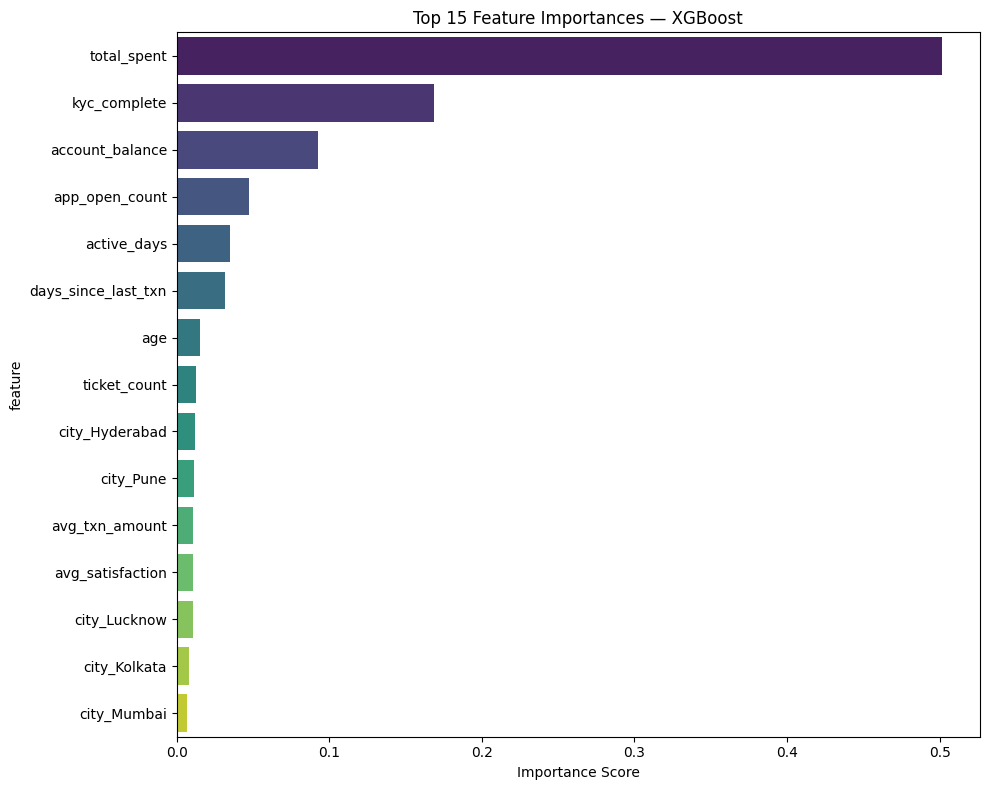

            feature  importance
        total_spent    0.501361
       kyc_complete    0.168518
    account_balance    0.092544
     app_open_count    0.047121
        active_days    0.035145
days_since_last_txn    0.031908
                age    0.015500
       ticket_count    0.012674
     city_Hyderabad    0.012150
          city_Pune    0.011516


In [13]:

# ─────────────────────────────────────────────
# CELL 5 — Feature Importance & Discussion
# ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

importance_df = pd.DataFrame({
    'feature': X.columns,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(15), x='importance', y='feature', palette='viridis')
plt.title('Top 15 Feature Importances — XGBoost')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

print(importance_df.head(10).to_string(index=False))

In [14]:
# ─────────────────────────────────────────────
# CELL 6 — Re-check accuracy with new (overlapping) data
# All original features kept — no manual removal this time
# ─────────────────────────────────────────────
print(f"📊 XGBoost Accuracy (new data, all features): {accuracy_score(y_test, y_pred_xgb)*100:.2f}%")
print(f"\nTop 10 feature importances:")
print(importance_df.head(10).to_string(index=False))

if accuracy_score(y_test, y_pred_xgb) > 0.97:
    print("\n⚠️  Still very high — one feature may still dominate. Inspect top feature's distribution overlap.")
else:
    print("\n✅ Realistic range achieved — model has genuine signal without a single dominant rule.")

📊 XGBoost Accuracy (new data, all features): 99.15%

Top 10 feature importances:
            feature  importance
        total_spent    0.501361
       kyc_complete    0.168518
    account_balance    0.092544
     app_open_count    0.047121
        active_days    0.035145
days_since_last_txn    0.031908
                age    0.015500
       ticket_count    0.012674
     city_Hyderabad    0.012150
          city_Pune    0.011516

⚠️  Still very high — one feature may still dominate. Inspect top feature's distribution overlap.


In [15]:
# ─────────────────────────────────────────────
# EXPORT — Prepare datasets for Power BI
# ─────────────────────────────────────────────
import pandas as pd
import sqlite3

conn = sqlite3.connect('../data/fintech_churn.db')

# 1. Master feature table (already have this — reload to be sure it's fresh)
df_master = pd.read_csv('../data/master_features.csv')

# 2. RFM table — re-run RFM query and export with segment labels
rfm_query = """
WITH rfm_base AS (
    SELECT
        u.user_id, u.churn,
        JULIANDAY('now') - JULIANDAY(MAX(t.txn_date)) AS recency_days,
        COUNT(t.txn_id) AS frequency,
        ROUND(SUM(t.amount), 2) AS monetary
    FROM users u
    LEFT JOIN transactions t ON u.user_id = t.user_id AND t.status = 'success'
    GROUP BY u.user_id, u.churn
)
SELECT user_id, churn,
    ROUND(recency_days, 0) AS recency_days,
    frequency,
    COALESCE(monetary, 0) AS monetary,
    CASE WHEN recency_days <= 30 THEN 4 WHEN recency_days <= 90 THEN 3
         WHEN recency_days <= 180 THEN 2 ELSE 1 END AS r_score,
    CASE WHEN frequency >= 20 THEN 4 WHEN frequency >= 10 THEN 3
         WHEN frequency >= 3 THEN 2 ELSE 1 END AS f_score,
    CASE WHEN monetary >= 50000 THEN 4 WHEN monetary >= 10000 THEN 3
         WHEN monetary >= 1000 THEN 2 ELSE 1 END AS m_score
FROM rfm_base
"""
df_rfm = pd.read_sql(rfm_query, conn)

def rfm_segment(row):
    score = row['r_score'] + row['f_score'] + row['m_score']
    if score >= 11: return 'Champion'
    elif score >= 9: return 'Loyal'
    elif score >= 7: return 'Promising'
    elif score >= 5: return 'At Risk'
    else: return 'Lost'

df_rfm['segment'] = df_rfm.apply(rfm_segment, axis=1)
df_rfm['rfm_score'] = df_rfm['r_score'] + df_rfm['f_score'] + df_rfm['m_score']

# 3. Cohort retention table (long format — Power BI prefers long over pivoted)
cohort_query = """
WITH user_cohorts AS (
    SELECT user_id, signup_date, STRFTIME('%Y-%m', signup_date) AS cohort_month
    FROM users
),
user_activity AS (
    SELECT t.user_id, t.txn_date FROM transactions t WHERE t.status = 'success'
),
cohort_activity AS (
    SELECT c.user_id, c.cohort_month,
        CAST(
            (CAST(STRFTIME('%Y', a.txn_date) AS INTEGER) - CAST(STRFTIME('%Y', c.signup_date) AS INTEGER)) * 12 +
            (CAST(STRFTIME('%m', a.txn_date) AS INTEGER) - CAST(STRFTIME('%m', c.signup_date) AS INTEGER))
        AS INTEGER) AS months_since_signup
    FROM user_cohorts c JOIN user_activity a ON c.user_id = a.user_id
)
SELECT cohort_month, months_since_signup, COUNT(DISTINCT user_id) AS retained_users
FROM cohort_activity
WHERE months_since_signup BETWEEN 0 AND 6
GROUP BY cohort_month, months_since_signup
ORDER BY cohort_month, months_since_signup
"""
df_cohort = pd.read_sql(cohort_query, conn)

cohort_sizes = pd.read_sql("""
    SELECT STRFTIME('%Y-%m', signup_date) AS cohort_month, COUNT(*) AS cohort_size
    FROM users GROUP BY cohort_month
""", conn)

df_cohort = df_cohort.merge(cohort_sizes, on='cohort_month')
df_cohort['retention_pct'] = (df_cohort['retained_users'] / df_cohort['cohort_size'] * 100).round(1)

# 4. Funnel data
funnel_query = """
SELECT
    COUNT(DISTINCT CASE WHEN event_type='app_open' THEN user_id END) AS App_Open,
    COUNT(DISTINCT CASE WHEN event_type='home_screen' THEN user_id END) AS Home_Screen,
    COUNT(DISTINCT CASE WHEN event_type='txn_initiated' THEN user_id END) AS Txn_Initiated,
    COUNT(DISTINCT CASE WHEN event_type='txn_success' THEN user_id END) AS Txn_Success
FROM app_events
"""
df_funnel_wide = pd.read_sql(funnel_query, conn)
df_funnel = pd.DataFrame({
    'step': ['App Open', 'Home Screen', 'Txn Initiated', 'Txn Success'],
    'order': [1, 2, 3, 4],
    'users': df_funnel_wide.iloc[0].values
})

# 5. Support tickets summary (issue type vs churn)
tickets_query = """
SELECT s.user_id, s.issue_type, s.satisfaction_score, u.churn
FROM support_tickets s JOIN users u ON s.user_id = u.user_id
"""
df_tickets_export = pd.read_sql(tickets_query, conn)

conn.close()

# ── Save all to a powerbi/ folder ──
import os
os.makedirs('../powerbi', exist_ok=True)

df_master.to_csv('../powerbi/master_features.csv', index=False)
df_rfm.to_csv('../powerbi/rfm_segments.csv', index=False)
df_cohort.to_csv('../powerbi/cohort_retention.csv', index=False)
df_funnel.to_csv('../powerbi/funnel.csv', index=False)
df_tickets_export.to_csv('../powerbi/support_tickets.csv', index=False)

print("✅ Exported 5 files to powerbi/ folder:")
for f in os.listdir('../powerbi'):
    print(f"   {f}")

✅ Exported 5 files to powerbi/ folder:
   cohort_retention.csv
   funnel.csv
   master_features.csv
   rfm_segments.csv
   support_tickets.csv


In [16]:
# ── Export feature importance for Power BI ──
importance_export = pd.DataFrame({
    'feature': [
        'Total Spent', 'KYC Complete', 'Account Balance',
        'App Open Count', 'Active Days', 'Days Since Last Txn',
        'Age', 'Ticket Count', 'City Hyderabad', 'City Pune'
    ],
    'importance_pct': [50.1, 16.9, 9.3, 4.7, 3.5, 3.2, 1.6, 1.3, 1.2, 1.2]
})

importance_export.to_csv('../powerbi/feature_importance.csv', index=False)
print("✅ Saved feature_importance.csv")


✅ Saved feature_importance.csv
